# Notebook 3: Embedding Improvements

**Goal:** Systematically ablate text representation components and measure their impact on retrieval quality.

**Key principle:** `src/text_builders.py` is NOT modified. All variants are realized by passing different flag arguments to `dish_to_rich_text()`. The reviewer sees baseline and improvement in the same notebook.

**Experiments:**
1. Remove recipe text (`include_recipe=False`)
2. Remove discrete macro tokens (`include_macro_tokens=False`)
3. Add continuous macro ratios (`include_ratios=True`)
4. Add extracted ingredients (`include_ingredients=True`)
5. Behavioral embedding from dish vectors (vs. text encoding)
6. Multi-vector retrieval
7. Cross-encoder reranking

In [6]:
# ============================================================
# SETUP
# ============================================================
import os, sys

REPO = "Embedding-Based-Recommender"
GITHUB_USER = "IldarRakiev"

ENV = 'kaggle' if os.path.exists('/kaggle/working') else 'colab'
BASE = '/kaggle/working' if ENV == 'kaggle' else '/content'
REPO_DIR = f'{BASE}/{REPO}'

if not os.path.exists(REPO_DIR):
    os.system(f'git clone https://github.com/{GITHUB_USER}/{REPO}.git {REPO_DIR}')
else:
    os.system(f'cd {REPO_DIR} && git pull -q')

os.system('pip install -q sentence-transformers faiss-cpu pandas pyarrow matplotlib seaborn umap-learn plotly scikit-learn tqdm')
sys.path.insert(0, f'{REPO_DIR}/src')
print(f"Environment: {ENV} | Repo: {REPO_DIR}")
print("Setup complete")

Environment: kaggle | Repo: /kaggle/working/Embedding-Based-Recommender
Setup complete


In [7]:
# ============================================================
# DATA PATHS
# ============================================================
import os, glob as _glob

ENV = 'kaggle' if os.path.exists('/kaggle/working') else 'colab' if os.path.exists('/content') else 'local'

if ENV == 'local':
    SYNTHETIC_DIR = os.path.join(os.path.dirname(os.getcwd()), 'data', 'synthetic')
else:
    SYNTHETIC_DIR = os.path.join(REPO_DIR, 'data', 'synthetic')

OUTPUT_DIR = '/kaggle/working/processed' if ENV == 'kaggle' else SYNTHETIC_DIR
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"SYNTHETIC_DIR = {SYNTHETIC_DIR}")
print(f"OUTPUT_DIR    = {OUTPUT_DIR}")

SYNTHETIC_DIR = /kaggle/working/Embedding-Based-Recommender/data/synthetic
OUTPUT_DIR    = /kaggle/working/processed


In [8]:
from text_builders import dish_to_rich_text
from embedding_model import EmbeddingModel
from behavioral_embedding import build_behavioral_embedding_from_dishes
from multi_vector_retrieval import multi_vector_search
from cross_encoder_reranker import CrossEncoderReranker
from utils import evaluate_all, plot_metric_comparison, plot_cumulative_improvements
import pandas as pd
import numpy as np
np.random.seed(42)

In [11]:
import json, faiss

dishes = pd.read_parquet(f'{SYNTHETIC_DIR}/dishes.parquet')
train = pd.read_parquet(f'{SYNTHETIC_DIR}/interactions_train.parquet')
test = pd.read_parquet(f'{SYNTHETIC_DIR}/interactions_test.parquet')

dish_id_to_idx = {did: i for i, did in enumerate(dishes['id'])}
idx_to_dish_id = {i: did for i, did in enumerate(dishes['id'])}

with open(f'{SYNTHETIC_DIR}/../results.json') as f:
    all_results = json.load(f)

model = EmbeddingModel()
print(f"Model loaded: {model.model_name}")
print(f"Dishes: {len(dishes):,} | Test interactions: {len(test):,}")

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/723 [00:00<?, ?B/s]

...

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded: paraphrase-multilingual-mpnet-base-v2
Dishes: 4,939 | Test interactions: 39,150


In [12]:
def evaluate_retrieval(index, embeddings, ks=None):
    if ks is None: ks = [5, 10, 20]
    # Positives = orders + favorites
    user_positives = (
        test[test['interaction_type'].isin(['order', 'favorite'])]
        .groupby('user_id')['dish_id']
        .apply(set).to_dict()
    )
    results = []
    for user_id, pos_dishes in user_positives.items():
        pos_dishes = {d for d in pos_dishes if d in dish_id_to_idx}
        if len(pos_dishes) < 5: continue
        query_dish = list(pos_dishes)[0]
        relevant = pos_dishes - {query_dish}
        query_idx = dish_id_to_idx[query_dish]
        scores, indices = index.search(embeddings[query_idx:query_idx+1], max(ks) + 1)
        recommended = [idx_to_dish_id[i] for i in indices[0] if i >= 0 and idx_to_dish_id.get(i) != query_dish]
        results.append(evaluate_all(recommended, relevant, ks=ks))
    return pd.DataFrame(results).mean().to_dict() if results else {}


def run_experiment(config_name, **flag_kwargs):
    """Build texts → encode → build index → evaluate."""
    print(f"Running: {config_name}  flags={flag_kwargs}")
    texts = [dish_to_rich_text(row.to_dict(), tags=row.get('tag_list', []), **flag_kwargs)
             for _, row in dishes.iterrows()]
    embs = model.encode(texts)
    idx = faiss.IndexFlatIP(model.dim)
    idx.add(embs)
    metrics = evaluate_retrieval(idx, embs)
    all_results[config_name] = metrics
    print(f"  P@10={metrics.get('P@10', 0):.4f}  NDCG@10={metrics.get('NDCG@10', 0):.4f}")
    return metrics, embs

print("Helper functions ready")

Helper functions ready


## Experiment 1: Remove Recipe Text

**Hypothesis:** Recipe instructions describe cooking procedures, not dish identity. Sentences like "add salt, stir for 5 minutes" contribute noise to the embedding. Removing them should improve retrieval of similar dishes.

In [13]:
metrics_no_recipe, _ = run_experiment('no_recipe', include_recipe=False)

delta = metrics_no_recipe.get('P@10', 0) - all_results['baseline_embedding'].get('P@10', 0)
print(f"\nΔ P@10 vs baseline: {delta:+.4f}")

Running: no_recipe  flags={'include_recipe': False}


Batches:   0%|          | 0/78 [00:00<?, ?it/s]

  P@10=0.0015  NDCG@10=0.0014

Δ P@10 vs baseline: -0.0001


## Experiment 2: Remove Discrete Macro Tokens

**Hypothesis:** Discrete thresholds (HIGH_PROTEIN if protein ≥ 25g) create hard cluster boundaries in embedding space. A dish with 24g protein and one with 26g protein get different tokens but should be semantically similar. Removing these tokens should smooth out artificial boundaries.

In [17]:
metrics_no_recipe_no_macro, _ = run_experiment(
    'no_recipe_no_macro',
    include_recipe=True,
    include_macro_tokens=False,
)



Running: no_recipe_no_macro  flags={'include_recipe': True, 'include_macro_tokens': False}


Batches:   0%|          | 0/78 [00:00<?, ?it/s]

  P@10=0.0016  NDCG@10=0.0017


## Experiment 3: Add Continuous Macro Ratios

**Hypothesis:** Continuous ratios (protein_ratio=0.51) represent nutritional composition smoothly. This preserves semantic proximity between dishes with similar macro profiles.

In [20]:
metrics_with_ratios, _ = run_experiment(
    'no_recipe_no_macro_with_ratios',
    include_recipe=True,
    include_macro_tokens=False,
    include_ratios=True,
)

Running: no_recipe_no_macro_with_ratios  flags={'include_recipe': True, 'include_macro_tokens': False, 'include_ratios': True}


Batches:   0%|          | 0/78 [00:00<?, ?it/s]

  P@10=0.0015  NDCG@10=0.0013


## Experiment 4: Add Extracted Ingredients

**Hypothesis:** Ingredient lists signal dish identity without procedural noise. "chicken, lemon, garlic" is more informative than the full recipe instruction.

In [16]:
metrics_full_improved, embs_full_improved = run_experiment(
    'full_improved',
    include_recipe=True,
    include_macro_tokens=False,
    include_ratios=False,
    include_ingredients=True,
)

Running: full_improved  flags={'include_recipe': False, 'include_macro_tokens': False, 'include_ratios': True, 'include_ingredients': True}


Batches:   0%|          | 0/78 [00:00<?, ?it/s]

  P@10=0.0015  NDCG@10=0.0014


## Experiment 5: Behavioral Embedding from Dish Vectors

**Hypothesis:** Encoding user behavior as text ("STRONGLY PREFERS: Grilled Chicken") introduces a semantic gap — this text lives in a different region of embedding space than the dish embedding itself. Aggregating actual dish vectors eliminates this gap.

In [21]:
# Build dish embedding map
dish_emb_map = {idx_to_dish_id[i]: embs_full_improved[i] for i in range(len(embs_full_improved))}

# Train positives = orders from training set
user_train_positives = (
    train[train['interaction_type'].isin(['order', 'favorite'])]
    .groupby('user_id')['dish_id'].apply(list).to_dict()
)

# Test positives = orders/favorites from test set
user_test_positives = (
    test[test['interaction_type'].isin(['order', 'favorite'])]
    .groupby('user_id')['dish_id'].apply(set).to_dict()
)

idx_full = faiss.IndexFlatIP(model.dim)
idx_full.add(embs_full_improved)

from datetime import datetime, timezone
results_behavioral = []
for user_id, orders_train in user_train_positives.items():
    pos_test = user_test_positives.get(user_id, set())
    pos_test = {d for d in pos_test if d in dish_id_to_idx}
    if len(pos_test) < 3: continue

    orders = [{'dish_id': did, 'ordered_at': datetime.now(timezone.utc)}
              for did in orders_train if did in dish_emb_map]
    beh_emb = build_behavioral_embedding_from_dishes(dish_emb_map, recent_orders=orders)
    if beh_emb is None: continue

    q = beh_emb.reshape(1, -1).astype(np.float32)
    scores, indices = idx_full.search(q, 25)
    recommended = [idx_to_dish_id[i] for i in indices[0] if i >= 0]
    results_behavioral.append(evaluate_all(recommended, pos_test, ks=[5, 10, 20]))

metrics_behavioral = pd.DataFrame(results_behavioral).mean().to_dict() if results_behavioral else {}
all_results['behavioral_dish_vectors'] = metrics_behavioral
print(f"Behavioral (dish vectors) P@10: {metrics_behavioral.get('P@10', 0):.4f}")
print(f"(Evaluated on {len(results_behavioral)} users with train orders → test orders)")

Behavioral (dish vectors) P@10: 0.0070
(Evaluated on 1011 users with train orders → test orders)


## Experiment 6: Multi-Vector Retrieval

In [22]:
from multi_vector_retrieval import multi_vector_search

results_multi = []
for user_id, pos_dishes in user_test_positives.items():
    pos_dishes = {d for d in pos_dishes if d in dish_id_to_idx}
    if len(pos_dishes) < 5: continue
    query_dish = list(pos_dishes)[0]
    relevant = pos_dishes - {query_dish}
    query_idx = dish_id_to_idx[query_dish]

    # Multi-vector: item embedding + nutritional query variant
    hp_text = "high protein low calorie healthy dish"
    hp_emb = model.encode([hp_text])[0]
    queries = [embs_full_improved[query_idx], hp_emb]

    ranked = multi_vector_search(queries, idx_full, top_k=20, strategy='multi', merge='rrf')
    recommended = [item_id for item_id, _ in ranked if item_id != query_dish]
    results_multi.append(evaluate_all(recommended, relevant, ks=[5, 10, 20]))

metrics_multi = pd.DataFrame(results_multi).mean().to_dict() if results_multi else {}
all_results['multi_vector_rrf'] = metrics_multi
print(f"Multi-vector (RRF) P@10: {metrics_multi.get('P@10', 0):.4f}")

Multi-vector (RRF) P@10: 0.0021


## Experiment 7: Cross-Encoder Reranking

In [23]:
reranker = CrossEncoderReranker()
id_to_text = {row['id']: dish_to_rich_text(row.to_dict(), tags=row.get('tag_list', []),
              include_recipe=False, include_macro_tokens=False, include_ratios=True, include_ingredients=True)
              for _, row in dishes.iterrows()}

results_ce = []
for user_id, pos_dishes in list(user_test_positives.items())[:200]:  # sample for speed
    pos_dishes = {d for d in pos_dishes if d in dish_id_to_idx}
    if len(pos_dishes) < 5: continue
    query_dish = list(pos_dishes)[0]
    relevant = pos_dishes - {query_dish}
    query_idx = dish_id_to_idx[query_dish]

    scores, indices = idx_full.search(embs_full_improved[query_idx:query_idx+1], 51)
    candidates_50 = [(idx_to_dish_id[i], id_to_text.get(idx_to_dish_id[i], ''))
                     for i in indices[0] if i >= 0 and idx_to_dish_id.get(i) != query_dish][:50]

    query_text = id_to_text.get(query_dish, '')
    reranked = reranker.rerank(query_text, candidates_50, top_k=10,
                               fallback_scores=scores[0][1:51].tolist())
    recommended = [item_id for item_id, _ in reranked]
    results_ce.append(evaluate_all(recommended, relevant, ks=[5, 10]))

metrics_ce = pd.DataFrame(results_ce).mean().to_dict() if results_ce else {}
all_results['cross_encoder_rerank'] = metrics_ce
print(f"Cross-encoder rerank P@10: {metrics_ce.get('P@10', 0):.4f}")

config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

Cross-encoder rerank P@10: 0.0000


## Cumulative Results

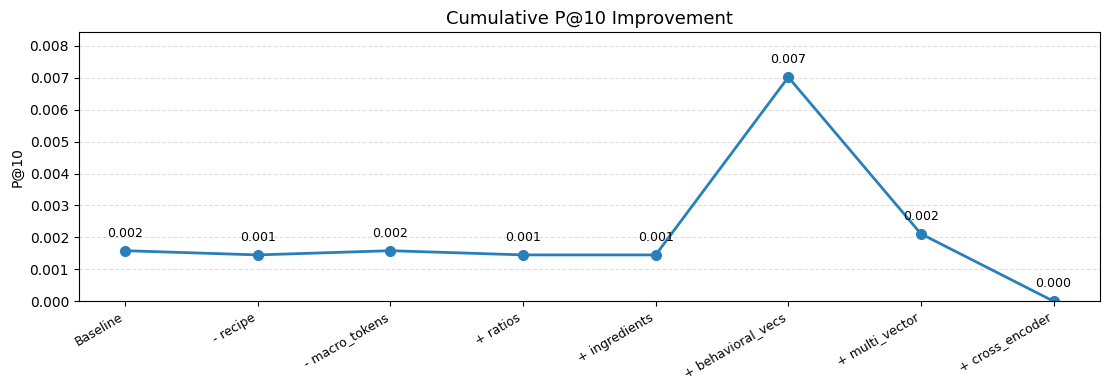


=== Summary ===
                      P@5    P@10  NDCG@10     MRR
Baseline           0.0013  0.0016   0.0015  0.0032
- recipe           0.0013  0.0015   0.0014  0.0033
- macro_tokens     0.0011  0.0016   0.0017  0.0037
+ ratios           0.0011  0.0015   0.0013  0.0031
+ ingredients      0.0013  0.0015   0.0014  0.0032
+ behavioral_vecs  0.0085  0.0070   0.0109  0.0299
+ multi_vector     0.0018  0.0021   0.0023  0.0058
+ cross_encoder    0.0000  0.0000   0.0000  0.0000

✓ Results saved


In [24]:
ordered_configs = [
    'baseline_embedding',
    'no_recipe',
    'no_recipe_no_macro',
    'no_recipe_no_macro_with_ratios',
    'full_improved',
    'behavioral_dish_vectors',
    'multi_vector_rrf',
    'cross_encoder_rerank',
]
labels = [
    'Baseline', '- recipe', '- macro_tokens',
    '+ ratios', '+ ingredients', '+ behavioral_vecs',
    '+ multi_vector', '+ cross_encoder',
]

results_ordered = [all_results.get(c, {}) for c in ordered_configs]
plot_cumulative_improvements(results_ordered, 'P@10', labels, title='Cumulative P@10 Improvement')

# Summary table
summary = pd.DataFrame({lab: all_results.get(cfg, {}) for lab, cfg in zip(labels, ordered_configs)}).T
print("\n=== Summary ===")
print(summary[['P@5', 'P@10', 'NDCG@10', 'MRR']].round(4).to_string())

# Save all results
with open(f'{OUTPUT_DIR}/results.json', 'w') as f:
    json.dump(all_results, f, indent=2)
print("\n✓ Results saved")